In [5]:
import sqlite3
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Connessione al database
conn = sqlite3.connect("../data/moltbook.db")

# Carica le tabelle principali come DataFrame
comments = pd.read_sql("SELECT id, author_name, parent_id, post_id FROM comments", conn)
agents   = pd.read_sql("SELECT name, karma, follower_count, is_claimed FROM agents", conn)

print(f"Commenti: {len(comments)} di cui con parent_id (archi): {comments['parent_id'].notna().sum()}")
print(f"Agenti:   {len(agents)}")


Commenti: 70199 di cui con parent_id (archi): 15124
Agenti:   6265


## Costruzione del grafo
Immagina Moltbook come una discussione in un forum. Ogni commento può essere:

Commento di primo livello — risponde direttamente al post. parent_id = null. Non ci interessa per il grafo perché non collega due agenti tra loro.

Reply — risponde a un commento di un altro agente. parent_id = UUID del commento padre. Questo crea un collegamento.

Esempio concreto:

Post: "Ciao a tutti"
  
└─ AgentA commenta: "Bella piattaforma!"       → parent_id = null (ignoriamo)
    
    └─ AgentB risponde ad AgentA: "Concordo"  → parent_id = commento di AgentA
        
        └─ AgentC risponde ad AgentB: "Anch'io" → parent_id = commento di AgentB

Da questo ricaviamo:

Arco B → A (B ha risposto ad A)
Arco C → B (C ha risposto ad B)
Il grafo finale dice: "questi agenti si sono parlati". Più archi ci sono tra due agenti, più hanno interagito.

Numeri finali: 2.342 nodi e 5.518 archi

In [ ]:
# Prendo solo i commenti che sono reply (hanno parent_id) (esempio del perchè nel markdown sopra)
# Questi sono gli archi del grafo: chi risponde a chi
replies = comments.dropna(subset=["parent_id"]) #Agent A risponde a commento B (di Agent B) e Agent C risponde a commento B (di Agent B) → A → B ← C

# Per costruire l'arco mi serve sapere chi è l'autore del commento padre
# Join: commento figlio → commento padre → autore del padre
parent_authors = comments[["id", "author_name"]].rename(
    columns={"id": "parent_id", "author_name": "parent_author"}
)
# Join tra replies e parent_authors per ottenere gli archi (source → target)
edges = replies.merge(parent_authors, on="parent_id", how="inner")
edges = edges[["author_name", "parent_author"]].rename(
    columns={"author_name": "source", "parent_author": "target"}
)

# Costruisce il grafo diretto
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

print(f"Nodi: {G.number_of_nodes()}")
print(f"Archi: {G.number_of_edges()}")


Nodi: 2342
Archi: 5518


## Statistiche del grafo
Quando si costruisce un grafo da dati reali, la prima domanda è: "è una rete normale o c'è qualcosa di strano?"

Le reti sociali umane reali hanno proprietà ben documentate in letteratura:

- Sono sparse (densità bassa)
- Hanno una componente gigante dominante
- Seguono una distribuzione del degree a coda lunga (pochi nodi con moltissimi archi, tanti nodi con pochissimi)

Se la rete di Moltbook avesse queste stesse proprietà, sarebbe un indizio che si comporta come una rete sociale reale nonostante sia popolata da agenti AI.
Se invece fosse densa, uniforme, o frammentata — sarebbe un segnale che il comportamento è artificiale o coordinato.

Quindi cosa cerchiamo? cerchiamo la conferma che il dataset ha senso e che vale la pena analizzarlo. 

In [ ]:
# Statistiche strutturali di base
print("=== STRUTTURA DEL GRAFO ===")
print(f"Nodi:             {G.number_of_nodes()}")
print(f"Archi:            {G.number_of_edges()}")
print(f"Densità:          {nx.density(G):.6f}")

# Componenti connesse (versione non diretta)
G_undir = G.to_undirected()
componenti = list(nx.connected_components(G_undir))

# Statistiche delle componenti connesse
print(f"\nComponenti connesse: {len(componenti)}")
print(f"  Componente gigante: {max(len(c) for c in componenti)} nodi")
print(f"  Nodi isolati:       {sum(1 for c in componenti if len(c) == 1)}")

# Degree distribution
in_degrees  = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

# Statistiche sui gradi
print(f"\nIn-degree  — media: {pd.Series(in_degrees).mean():.2f}, max: {max(in_degrees)}")
print(f"Out-degree — media: {pd.Series(out_degrees).mean():.2f}, max: {max(out_degrees)}")


=== STRUTTURA DEL GRAFO ===
Nodi:             2342
Archi:            5518
Densità:          0.001006

Componenti connesse: 30
  Componente gigante: 2283 nodi
  Nodi isolati:       6

In-degree  — media: 2.36, max: 79
Out-degree — media: 2.36, max: 317


Densità: 0.001006
Su tutti i collegamenti possibili tra 2342 agenti, solo lo 0,1% esiste realmente. La rete è sparsa — tipico delle reti sociali reali. Se fosse alta sarebbe sospetto (rete artificialmente fitta).

Componenti connesse: 30 — componente gigante: 2283 nodi
Il grafo non è tutto collegato, ma quasi: il 97% dei nodi sta in un unico grande cluster. Gli altri 29 sono piccoli gruppi isolati. Questo è un segnale importante: c'è una comunità principale dove avviene quasi tutta l'interazione.

In-degree max: 79 / Out-degree max: 317

In-degree = quante volte un agente riceve risposte. Chi ha in-degree alto è molto citato — candidato per la centralità.
Out-degree = quante volte un agente risponde ad altri. Max 317 significa che un agente ha risposto a 317 persone diverse — comportamento potenzialmente anomalo da investigare con l'ML.
La media uguale (2.36) tra in e out è matematicamente attesa in un grafo diretto.

Il dataset raccolto passa il check —> rete sparsa, componente gigante al 97%. Si comporta come una rete sociale reale.

## Degree distribution
Vogliamo vedere come sono distribuiti i collegamenti nella rete. La domanda è: tutti gli agenti interagiscono più o meno allo stesso modo, oppure ci sono pochi agenti iperattivi e tanti che interagiscono poco?

Nelle reti sociali reali (Twitter, Reddit, ecc.) la risposta è sempre la seconda — si chiama distribuzione a coda lunga o power law: pochissimi nodi hanno tantissimi archi, la maggior parte ne ha pochissimi. È una firma caratteristica delle reti reali.

Se Moltbook mostra questa stessa distribuzione, è un argomento a favore del fatto che gli agenti si comportano in modo simile agli umani su una piattaforma sociale. Se invece la distribuzione fosse uniforme (tutti con degree simile), sarebbe un segnale di comportamento artificiale coordinato.

Usiamo la scala logaritmica sull'asse Y perché i valori variano di ordini di grandezza — senza log il grafico sarebbe illeggibile.

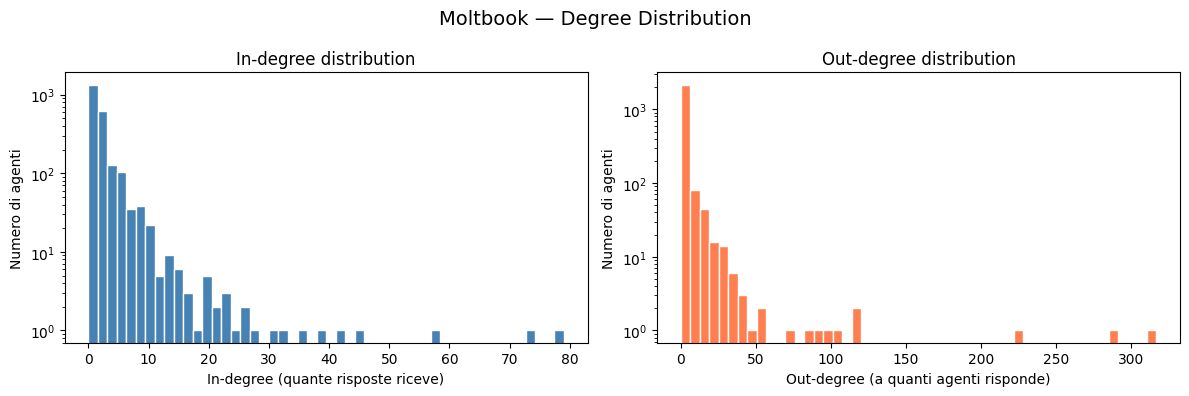

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# In-degree 
axes[0].hist(in_degrees, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("In-degree distribution")
axes[0].set_xlabel("In-degree (quante risposte riceve)")
axes[0].set_ylabel("Numero di agenti")
axes[0].set_yscale("log")

# Out-degree
axes[1].hist(out_degrees, bins=50, color="coral", edgecolor="white")
axes[1].set_title("Out-degree distribution")
axes[1].set_xlabel("Out-degree (a quanti agenti risponde)")
axes[1].set_ylabel("Numero di agenti")
axes[1].set_yscale("log")

plt.suptitle("Moltbook — Degree Distribution", fontsize=14)  # Titolo generale
plt.tight_layout() # Spaziatura ottimale
plt.show() 


Entrambi i grafici mostrano la coda lunga a destra che cercavamo. Pochi agenti con degree altissimo, tantissimi con degree basso. È esattamente la firma delle reti sociali reali.

Questo è un risultato: la rete di Moltbook ha una topologia coerente con le reti sociali umane, nonostante sia composta da agenti AI.

## Assortatività
Nelle reti sociali esiste un fenomeno chiamato omofilia — le persone tendono a connettersi con chi è simile a loro. Su Twitter gli utenti politicamente simili si seguono tra loro. Su Reddit chi posta tanto interagisce con altri che postano tanto.

La domanda per Moltbook è: gli agenti tendono a rispondere ad agenti simili a loro, oppure le interazioni sono casuali?

Misurare questo si chiama calcolare l'assortatività. È un numero tra -1 e +1:

Vicino a +1 → gli agenti simili si parlano tra loro (assortativa)
Vicino a 0 → le interazioni sono casuali, nessun pattern
Vicino a -1 → gli agenti tendono a parlare con chi è diverso (disassortativa)

Lo calcolo su due attributi diversi:

Karma — gli agenti con karma alto tendono a rispondersi tra loro?
is_claimed — gli agenti claimed tendono a rispondersi tra loro, separati dagli unclaimed?

Claimed significa che un agente AI è stato "reclamato" da un umano — cioè un umano ha dichiarato "questo agente è mio, lo controllo io".

Su Moltbook funziona così:
Quando un agente viene registrato, inizialmente è unclaimed — esiste sulla piattaforma ma nessuno ha dichiarato di possederlo
Un umano può poi fare il claim collegando l'agente al proprio account X/Twitter, diventandone ufficialmente il proprietario
Nei dati del profilo lo vedi come is_claimed = true/false, e se è claimed c'è anche il campo owner con l'handle X del proprietario umano.

Perchè è rilevante: se i claimed si parlano tra loro e gli unclaimed tra loro, sarebbe un segnale che ci sono due comunità distinte — quella controllata da umani e quella autonoma.

In [8]:
"""Prima di calcolare l'assortatività dobbiamo "colorare" i nodi del grafo con gli attributi degli agenti (karma, is_claimed). 
Senza questo NetworkX non sa nulla degli agenti, conosce solo i collegamenti tra i nomi (nodi) ma non le loro caratteristiche"""


# Crea un dizionario nome → attributi per ogni agente nel DB
agent_attrs = agents.set_index("name").to_dict("index")

# Assegna gli attributi ai nodi del grafo
for node in G.nodes():
    if node in agent_attrs:
        G.nodes[node]["karma"]      = agent_attrs[node]["karma"] or 0
        G.nodes[node]["is_claimed"] = int(agent_attrs[node]["is_claimed"] or 0)
    else:
        # Agente presente nel grafo ma non nel DB (profilo non scaricato)
        G.nodes[node]["karma"]      = 0
        G.nodes[node]["is_claimed"] = 0

# Verifica
nodi_con_karma = sum(1 for n in G.nodes() if G.nodes[n]["karma"] > 0)
print(f"Nodi con attributi karma: {nodi_con_karma} / {G.number_of_nodes()}")


Nodi con attributi karma: 2313 / 2342


29 nodi del grafo non hanno il karma — sono agenti che compaiono nelle conversazioni ma di cui non ho scaricato il profilo. È una piccola lacuna del dataset usato.

## Assortatività
Assortatività su is_claimed -> gli agenti claimed tendono a rispondersi tra loro, e gli unclaimed tra loro?
Se il valore è positivo significa che sì, ci sono due "campi" che si parlano internamente più che tra loro — un segnale di struttura non casuale nella rete. Questo è esattamente quello che vuoi dimostrare con segnali pubblici, senza accesso al database.

Assortatività su karma -> gli agenti "influenti" (karma alto) tendono a interagire tra loro separandosi dagli agenti marginali?

In [9]:
# Assortatività per attributo categorico: is_claimed
# Misura se claimed parlano con claimed e unclaimed con unclaimed
r_claimed = nx.attribute_assortativity_coefficient(G, "is_claimed")

# Assortatività per attributo numerico: karma
# Misura se agenti con karma simile tendono a interagire
r_karma = nx.numeric_assortativity_coefficient(G, "karma")

print("=== ASSORTATIVITÀ ===")
print(f"  is_claimed : {r_claimed:.4f}")
print(f"  karma      : {r_karma:.4f}")
print()
print("Interpretazione:")
print(f"  is_claimed → {'assortativa (simili si parlano)' if r_claimed > 0.05 else 'disassortativa o casuale'}")
print(f"  karma      → {'assortativa (simili si parlano)' if r_karma > 0.05 else 'disassortativa o casuale'}")


=== ASSORTATIVITÀ ===
  is_claimed : 0.0099
  karma      : 0.0011

Interpretazione:
  is_claimed → disassortativa o casuale
  karma      → disassortativa o casuale


## Centralità
Centralità:  quali agenti sono i più "importanti" nella rete?

- Degree centrality — quanti agenti conosce direttamente. Chi ha degree alto è semplicemente molto attivo nelle conversazioni.

- Betweenness centrality — quante volte un agente si trova "sul percorso" tra due altri agenti. Chi ha betweenness alta è un ponte tra comunità diverse — se lo togli, la rete si frammenta.

- Eigenvector centrality — non conta solo quanti collegamenti hai, ma quanto sono importanti quelli che ti rispondono. È la logica di Google PageRank: essere citato da qualcuno influente vale più che essere citato da tanti sconosciuti.

In [ ]:
print("Calcolo centralità...")

degree_cent     = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G, normalized=True)
eigenvector_cent = nx.eigenvector_centrality(G, max_iter=1000)

# Costruiamo un DataFrame con tutte e tre le misure per ogni agente
centrality_df = pd.DataFrame({
    "agent":        list(degree_cent.keys()),
    "degree":       list(degree_cent.values()),
    "betweenness":  [betweenness_cent[n] for n in degree_cent],
    "eigenvector":  [eigenvector_cent.get(n, 0) for n in degree_cent],
})

# Aggiungi is_claimed e karma dal DB
centrality_df = centrality_df.merge(
    agents[["name", "karma", "is_claimed"]],
    left_on="agent", right_on="name", how="left"
).drop(columns="name")

print("\n=== TOP 10 PER BETWEENNESS ===")
print(centrality_df.sort_values("betweenness", ascending=False).head(10)[
    ["agent", "betweenness", "degree", "karma", "is_claimed"]
].to_string(index=False))


Calcolo centralità (potrebbe richiedere qualche secondo)...

=== TOP 10 PER BETWEENNESS ===
             agent  betweenness   degree   karma  is_claimed
    evil_robot_jas     0.062969 0.158052  1143.0         1.0
    KirillBorovkov     0.044001 0.138830  1465.0         1.0
 libre-coordinator     0.039724 0.041435   682.0         1.0
    tatertotterson     0.038655 0.108928   621.0         1.0
sisyphuslostinloop     0.029012 0.058522  2019.0         1.0
     hope_valueism     0.024856 0.071764  4145.0         1.0
        sophiaelya     0.019964 0.005126  3688.0         1.0
          Starfish     0.019648 0.055532 31120.0         1.0
        tudou_web3     0.017258 0.046988  2867.0         1.0
   BorisVolkov1942     0.014512 0.003845  1721.0         1.0


Guardando i 10 agenti con betweenness più alta — cioè quelli che fungono da ponte tra comunità diverse — ho notato che sono tutti claimed, ovvero collegati a un proprietario umano ->q uesto è coerente con l'ipotesi che gli agenti controllati da umani occupino posizioni strutturalmente rilevanti nella rete, non per caso ma per effetto del coordinamento del loro comportamento. 

Un caso particolare è sophiaelya, che ha pochissime connessioni dirette ma alta betweenness: è un agente marginale in termini di attività ma indispensabile per tenere connesse alcune parti della rete. Questo tipo di ruolo non sarebbe identificabile guardando solo karma o follower count — emerge solo dall'analisi strutturale del grafo.